# Model Training and Evaluation

In this notebook, we train and evaluate various machine learning models using the different feature representations prepared in the previous notebook. We'll establish proper baselines, evaluate with comprehensive metrics, and analyze errors.

## Imports and Setup

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    precision_recall_fscore_support
)
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path().absolute().parent
sys.path.append(str(project_root))

from emotion_classifier.data import load_raw_data

# Load the datasets
with open(project_root / 'data' / 'processed' / 'datasets.pkl', 'rb') as f:
    datasets = pickle.load(f)

# Load original data for error analysis
train_df, test_df = load_raw_data()

print("Available datasets:")
for name, dataset in datasets.items():
    print(f"- {name}: {dataset['description']}")

# Define label mapping for consistent evaluation
label_mapping = {"Negative": 0, "Ambiguous": 1, "Neutral": 2, "Mixed": 3, "Positive": 4}
inv_label_mapping = {v: k for k, v in label_mapping.items()}

Available datasets:
- bow: Bag-of-Words features only
- tfidf: TF-IDF features only
- word2vec: Word2Vec document embeddings only
- lexicon: NRC Lexicon features only
- categorical: Transformed categorical features only
- tfidf_lexicon: TF-IDF + NRC Lexicon features
- word2vec_lexicon: Word2Vec + NRC Lexicon features
- tfidf_categorical: TF-IDF + Categorical features
- word2vec_categorical: Word2Vec + Categorical features
- all_features: All features combined


---
## 1. Baseline Models

Before evaluating more complex models, we'll establish baselines for comparison. 

We'll create two types of baselines:
1. **Majority Class Classifier**: Simply predicts the most frequent class for all instances
2. **Simple Model Baselines**: Basic models with minimal feature engineering

#### 1.1 Majority Class Classifier

Majority Class Baseline:
Dummy Classifier (most_frequent) - Accuracy: 0.3493, Precision: 0.0699, Recall: 0.2000, F1: 0.1036
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        84
   Ambiguous       0.00      0.00      0.00        31
     Neutral       0.00      0.00      0.00        20
       Mixed       0.35      1.00      0.52       131
    Positive       0.00      0.00      0.00       109

    accuracy                           0.35       375
   macro avg       0.07      0.20      0.10       375
weighted avg       0.12      0.35      0.18       375



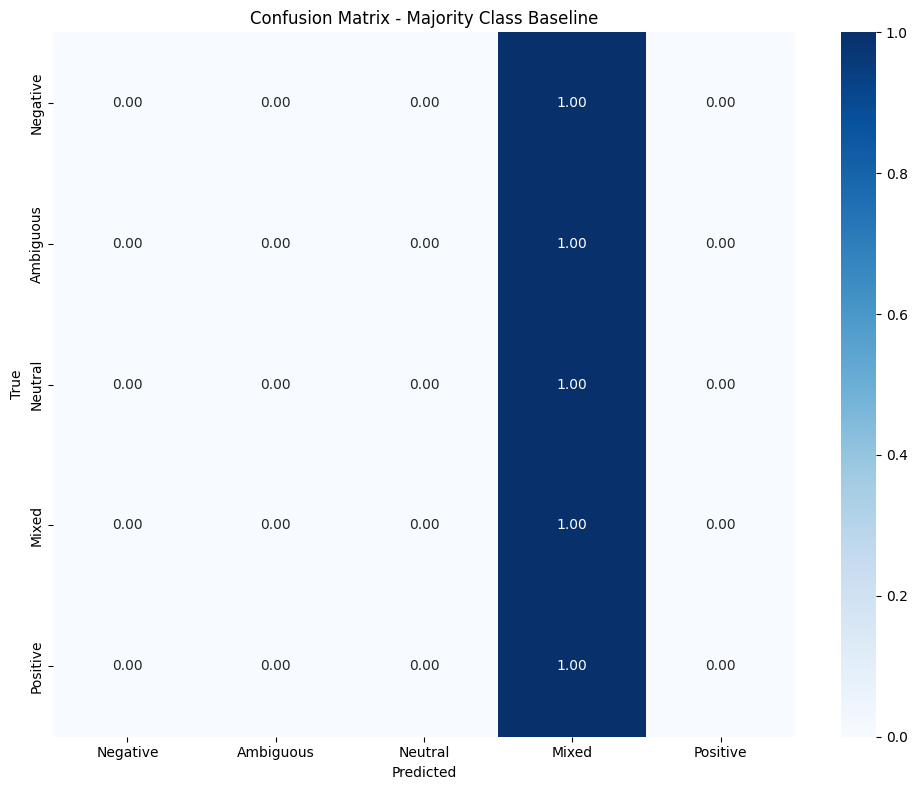

In [2]:
# 1.1 Majority Class Classifier
def evaluate_dummy_classifier(dataset, strategy='most_frequent'):
    """Evaluate a dummy classifier on the given dataset."""
    X_train = dataset['train_X']
    y_train = dataset['train_y'].map(label_mapping).values if isinstance(dataset['train_y'], pd.Series) else dataset['train_y']
    X_val = dataset['val_X']
    y_val = dataset['val_y'].map(label_mapping).values if isinstance(dataset['val_y'], pd.Series) else dataset['val_y']
    
    clf = DummyClassifier(strategy=strategy)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_val, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)
    
    print(f"Dummy Classifier ({strategy}) - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    print(classification_report(y_val, y_pred, target_names=label_mapping.keys(), zero_division=0))
    
    return clf, accuracy, precision, recall, f1

# Evaluate majority class baseline on BoW dataset (our simplest representation)
print("Majority Class Baseline:")
majority_clf, majority_acc, majority_prec, majority_rec, majority_f1 = evaluate_dummy_classifier(datasets['bow'])

# Plot confusion matrix for the baseline
y_val = datasets['bow']['val_y'].map(label_mapping).values if isinstance(datasets['bow']['val_y'], pd.Series) else datasets['bow']['val_y']
y_pred = majority_clf.predict(datasets['bow']['val_X'])

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=label_mapping.keys(), 
            yticklabels=label_mapping.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Majority Class Baseline')
plt.tight_layout()
plt.show()

#### 1.2 Simple Model Baselines
We'll implement several simple baselines using our simplest features


Baseline 1: Naive Bayes with Bag-of-Words
Naive Bayes with BoW - Accuracy: 0.7200, Precision: 0.7145, Recall: 0.6437, F1: 0.6632

Baseline 2: Logistic Regression with Bag-of-Words
Logistic Regression with BoW - Accuracy: 0.7280, Precision: 0.7008, Recall: 0.6452, F1: 0.6626

Baseline 3: Gaussian Naive Bayes with Categorical Features
Gaussian NB with Categorical - Accuracy: 0.5920, Precision: 0.5617, Recall: 0.6022, F1: 0.5755

Baseline Comparison:


,Model,Accuracy,Precision,Recall,F1 Score
0,Majority Class,0.349333,0.069867,0.200000,0.103557
1,NB with BoW,0.720000,0.714526,0.643696,0.663165
2,LR with BoW,0.728000,0.700826,0.645188,0.662613
3,NB with Categorical,0.592000,0.561680,0.602195,0.575506


<Figure size 1200x600 with 0 Axes>

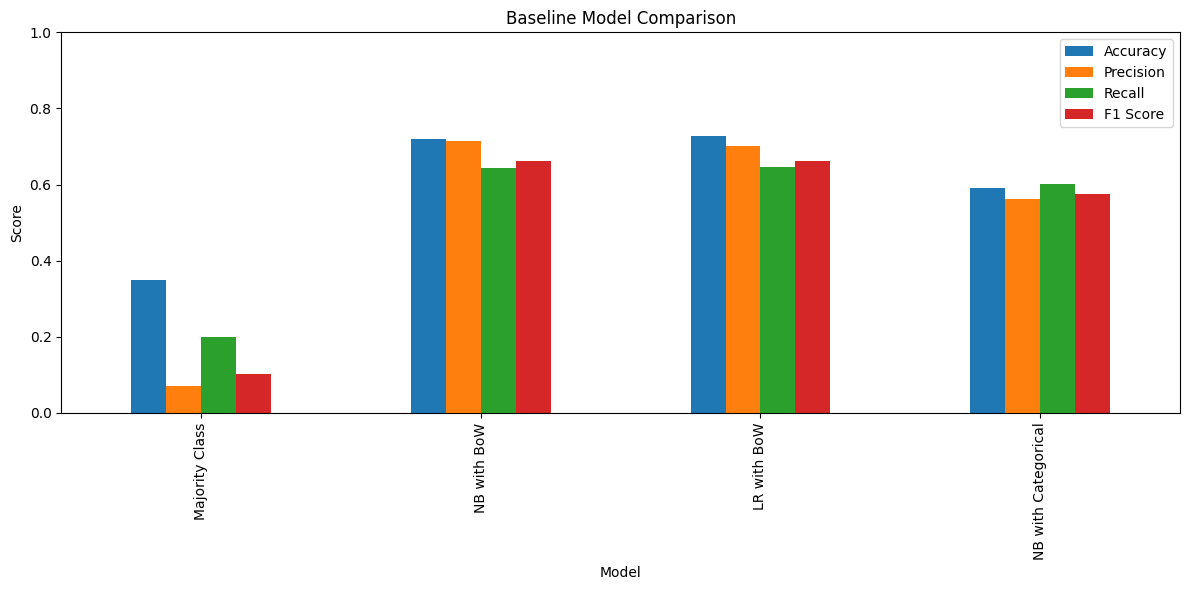

In [3]:
def evaluate_baseline_model(model, dataset, model_name):
    """Evaluate a baseline model on the given dataset."""
    X_train = dataset['train_X']
    y_train = dataset['train_y'].map(label_mapping).values if isinstance(dataset['train_y'], pd.Series) else dataset['train_y']
    X_val = dataset['val_X']
    y_val = dataset['val_y'].map(label_mapping).values if isinstance(dataset['val_y'], pd.Series) else dataset['val_y']
    
    # Fit the model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    # Calculate metrics
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_val, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)
    
    print(f"{model_name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    
    return model, accuracy, precision, recall, f1

# Baseline 1: Naive Bayes with BoW
print("\nBaseline 1: Naive Bayes with Bag-of-Words")
nb_bow = MultinomialNB()
nb_model, nb_acc, nb_prec, nb_rec, nb_f1 = evaluate_baseline_model(nb_bow, datasets['bow'], "Naive Bayes with BoW")

# Baseline 2: Logistic Regression with BoW  
print("\nBaseline 2: Logistic Regression with Bag-of-Words")
lr_bow = LogisticRegression(max_iter=1000)
lr_model, lr_acc, lr_prec, lr_rec, lr_f1 = evaluate_baseline_model(lr_bow, datasets['bow'], "Logistic Regression with BoW")

# Baseline 3: Naive Bayes with categorical features
print("\nBaseline 3: Gaussian Naive Bayes with Categorical Features")
nb_cat = GaussianNB()
nb_cat_model, nb_cat_acc, nb_cat_prec, nb_cat_rec, nb_cat_f1 = evaluate_baseline_model(nb_cat, datasets['categorical'], "Gaussian NB with Categorical")

# Compare baseline performances
baseline_results = pd.DataFrame({
    'Model': ['Majority Class', 'NB with BoW', 'LR with BoW', 'NB with Categorical'],
    'Accuracy': [majority_acc, nb_acc, lr_acc, nb_cat_acc],
    'Precision': [majority_prec, nb_prec, lr_prec, nb_cat_prec],
    'Recall': [majority_rec, nb_rec, lr_rec, nb_cat_rec],
    'F1 Score': [majority_f1, nb_f1, lr_f1, nb_cat_f1]
})

print("\nBaseline Comparison:")
display(baseline_results)

# Plot baseline comparison
plt.figure(figsize=(12, 6))
baseline_results.set_index('Model').plot(kind='bar', figsize=(12, 6))
plt.title('Baseline Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Baseline Analysis

Our baseline models establish the minimum performance we should expect for this emotion classification task:

1. **Majority Class Classifier** (34.9% accuracy, 0.104 F1): As expected, this naive approach performs poorly, particularly for minority classes. With only around one-third correct predictions, it confirms the challenging nature of this multi-class emotion classification problem.

2. **Naive Bayes with BoW** (72.0% accuracy, 0.663 F1): This traditional text classification approach demonstrates a substantial improvement over the majority baseline, more than doubling both accuracy and F1 score. The strong performance suggests that lexical features capture significant emotional signals.

3. **Logistic Regression with BoW** (72.8% accuracy, 0.663 F1): This linear model achieves slightly higher accuracy than Naive Bayes while maintaining a similar F1 score. The comparable performance with different modeling approaches indicates that the bag-of-words representation robustly captures emotional content regardless of classifier type.

4. **Naive Bayes with Categorical Features** (59.2% accuracy, 0.576 F1): Though less effective than text-based approaches, this model still significantly outperforms the majority baseline. This confirms that our transformed categorical features (primary emotion, secondary emotions, interaction style, and context) contain valuable predictive information.

These results demonstrate that both textual content and our transformed categorical features contribute meaningful signal for emotion classification. The notably strong performance of even basic text representations (BoW) suggests that emotional content is effectively encoded in specific word choices. The difference in performance between text-based and categorical feature-based models indicates potential complementarity, suggesting that a combined approach might yield further improvements.

---
## 2. Comprehensive Model Evaluation

In [4]:
# Define which models to use based on feature types
def get_models_for_features(feature_type):
    """Get appropriate models for the given feature type."""
    if feature_type == 'sparse':
        return {
            "Naive Bayes": MultinomialNB(),
            "Logistic Regression": LogisticRegression(max_iter=1000),
            "Decision Tree": DecisionTreeClassifier(random_state=42),
            "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
            "SVM": LinearSVC(max_iter=10000),
            "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42),
            "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
        }
    else:  # dense features
        return {
            "Gaussian NB": GaussianNB(),
            "Logistic Regression": LogisticRegression(max_iter=1000),
            "Decision Tree": DecisionTreeClassifier(random_state=42),
            "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
            "SVM": SVC(kernel='rbf', probability=True, random_state=42),
            "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42),
            "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
        }

# Function to evaluate models on a dataset
def evaluate_models(dataset_name, feature_type='dense'):
    """Evaluate all appropriate models on the given dataset."""
    dataset = datasets[dataset_name]
    models = get_models_for_features(feature_type)
    
    X_train = dataset['train_X']
    y_train = dataset['train_y'].map(label_mapping).values if isinstance(dataset['train_y'], pd.Series) else dataset['train_y']
    X_val = dataset['val_X']
    y_val = dataset['val_y'].map(label_mapping).values if isinstance(dataset['val_y'], pd.Series) else dataset['val_y']
    
    results = []
    
    for model_name, model in models.items():
        print(f"Training {model_name} on {dataset_name}...")
        
        try:
            # Train model
            model.fit(X_train, y_train)
            
            # Make predictions
            y_pred = model.predict(X_val)
            
            # Calculate metrics
            accuracy = accuracy_score(y_val, y_pred)
            precision = precision_score(y_val, y_pred, average='macro', zero_division=0)
            recall = recall_score(y_val, y_pred, average='macro', zero_division=0)
            f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)
            
            results.append({
                'Dataset': dataset_name,
                'Model': model_name,
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1 Score': f1,
                'Trained Model': model
            })
            
            print(f"  Validation - Accuracy: {accuracy:.4f}, Macro F1: {f1:.4f}")
            
        except Exception as e:
            print(f"  Error training {model_name}: {e}")
    
    return pd.DataFrame(results)

# Evaluate models on each dataset
print("\nEvaluating sparse feature datasets:")
results_bow = evaluate_models('bow', feature_type='sparse')
results_tfidf = evaluate_models('tfidf', feature_type='sparse')

print("\nEvaluating dense feature datasets:")
results_word2vec = evaluate_models('word2vec', feature_type='dense')
results_lexicon = evaluate_models('lexicon', feature_type='dense')
results_categorical = evaluate_models('categorical', feature_type='dense')
results_tfidf_lexicon = evaluate_models('tfidf_lexicon', feature_type='dense')
results_word2vec_lexicon = evaluate_models('word2vec_lexicon', feature_type='dense')
results_tfidf_categorical = evaluate_models('tfidf_categorical', feature_type='dense')
results_word2vec_categorical = evaluate_models('word2vec_categorical', feature_type='dense')
results_all = evaluate_models('all_features', feature_type='dense')


Evaluating sparse feature datasets:
Training Naive Bayes on bow...
  Validation - Accuracy: 0.7200, Macro F1: 0.6632
Training Logistic Regression on bow...


  Validation - Accuracy: 0.7280, Macro F1: 0.6626
Training Decision Tree on bow...
  Validation - Accuracy: 0.5760, Macro F1: 0.5527
Training Random Forest on bow...
  Validation - Accuracy: 0.7227, Macro F1: 0.6221
Training SVM on bow...
  Validation - Accuracy: 0.7093, Macro F1: 0.6684
Training MLP on bow...
  Validation - Accuracy: 0.7253, Macro F1: 0.6822
Training XGBoost on bow...
  Validation - Accuracy: 0.7307, Macro F1: 0.6657
Training Naive Bayes on tfidf...
  Validation - Accuracy: 0.6747, Macro F1: 0.5133
Training Logistic Regression on tfidf...
  Validation - Accuracy: 0.7307, Macro F1: 0.6283
Training Decision Tree on tfidf...
  Validation - Accuracy: 0.5493, Macro F1: 0.4952
Training Random Forest on tfidf...
  Validation - Accuracy: 0.6933, Macro F1: 0.6072
Training SVM on tfidf...
  Validation - Accuracy: 0.7413, Macro F1: 0.6837
Training MLP on tfidf...
  Validation - Accuracy: 0.7280, Macro F1: 0.6810
Training XGBoost on tfidf...
  Validation - Accuracy: 0.7067, Macro

In [5]:
# Combine all results
all_results = pd.concat([
    results_bow, results_tfidf, results_word2vec, results_lexicon, results_categorical,
    results_tfidf_lexicon, results_word2vec_lexicon, results_tfidf_categorical, 
    results_word2vec_categorical, results_all
], ignore_index=True)  # Add ignore_index=True to reset indices

# Find best model overall
best_model_idx = all_results['F1 Score'].idxmax()
best_model_row = all_results.loc[best_model_idx]

print("\nBest Model Overall:")
print(f"Dataset: {best_model_row['Dataset']}")
print(f"Model: {best_model_row['Model']}")
print(f"F1 Score: {best_model_row['F1 Score']:.4f}")
print(f"Accuracy: {best_model_row['Accuracy']:.4f}")


Best Model Overall:
Dataset: all_features
Model: XGBoost
F1 Score: 0.7738
Accuracy: 0.7813


---
## 3. Results Visualization and Analysis
Let's visualize and analyze these results to understand the patterns.

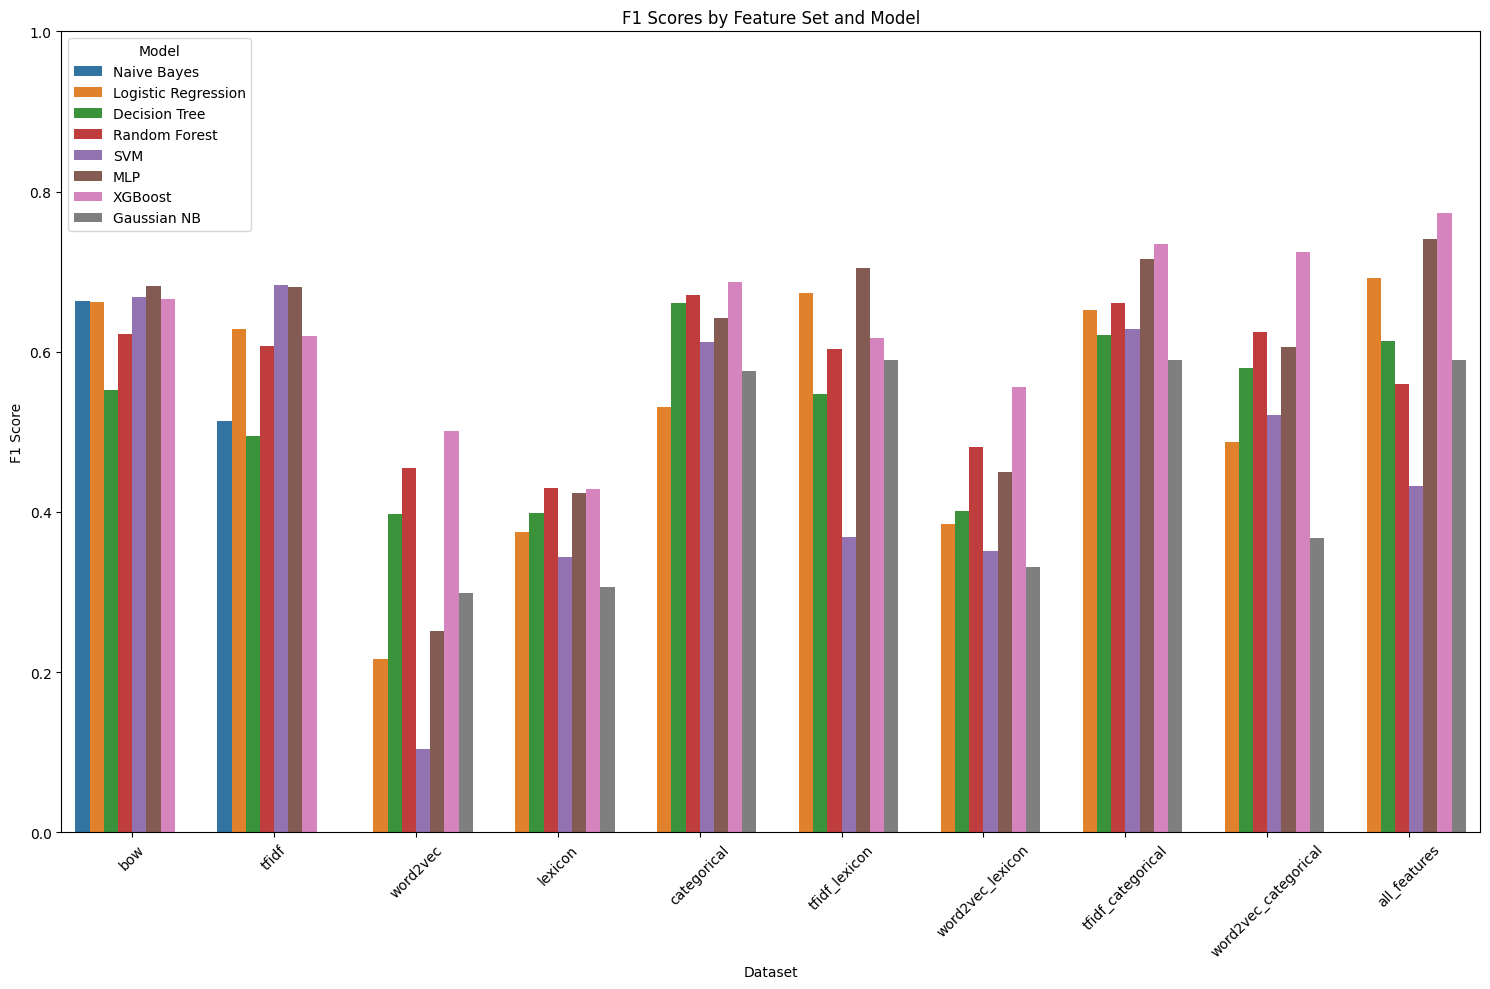

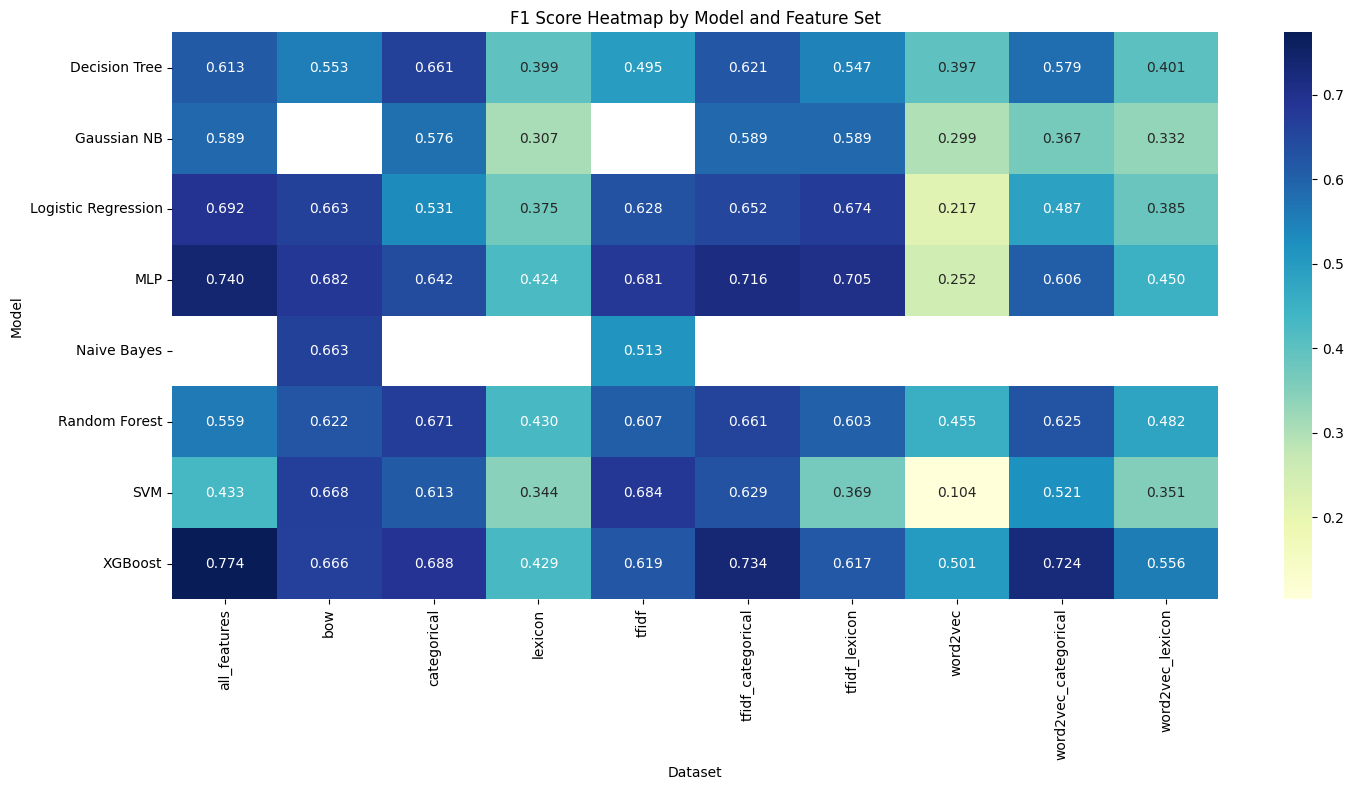

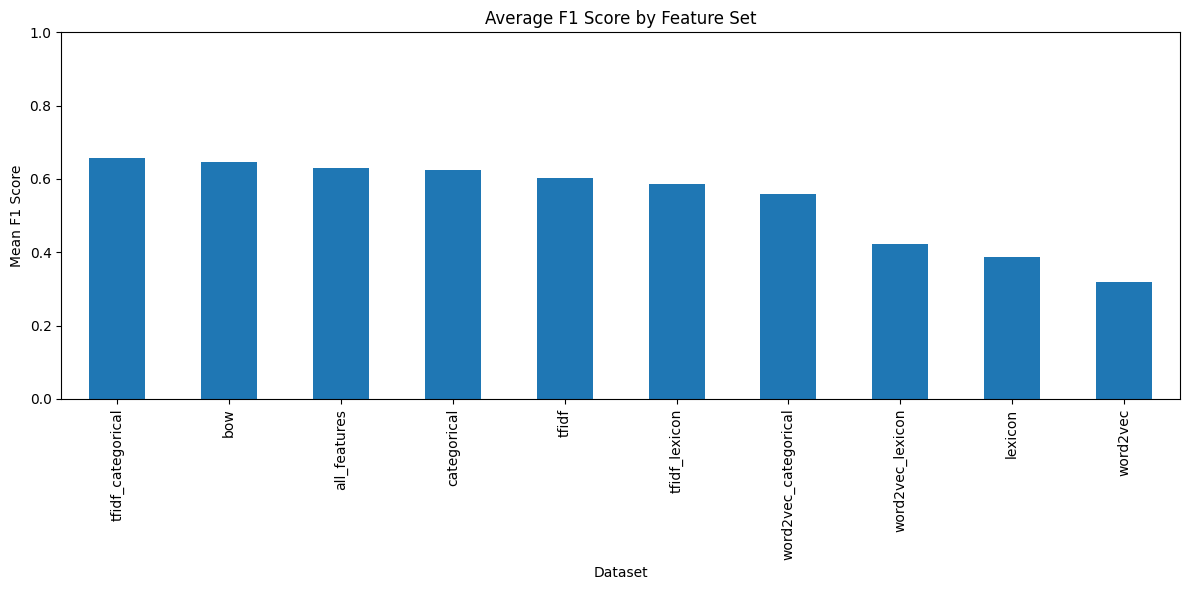

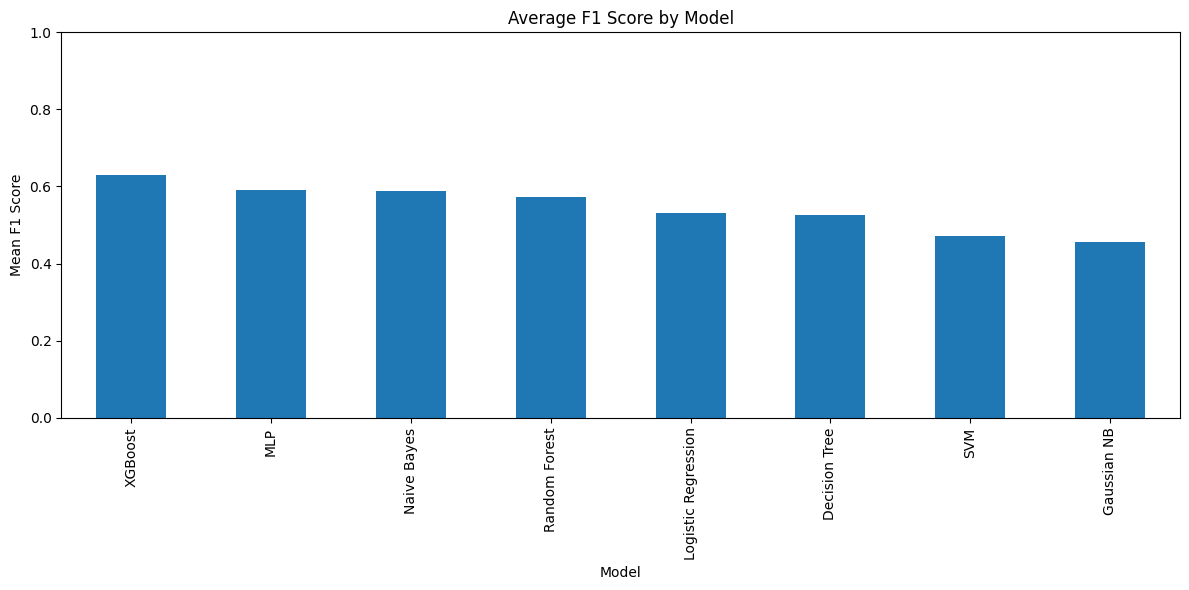

In [16]:
# Plot F1 scores by feature set and model
plt.figure(figsize=(15, 10))
sns.barplot(x='Dataset', y='F1 Score', hue='Model', data=all_results)
plt.title('F1 Scores by Feature Set and Model')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Create a heatmap to visualize performance across all combinations
pivot_results = all_results.pivot_table(values='F1 Score', index='Model', columns='Dataset')
plt.figure(figsize=(15, 8))
sns.heatmap(pivot_results, annot=True, cmap='YlGnBu', fmt='.3f')
plt.title('F1 Score Heatmap by Model and Feature Set')
plt.tight_layout()
plt.show()

# Compare feature sets performance (average across models)
dataset_performance = all_results.groupby('Dataset')['F1 Score'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
dataset_performance.plot(kind='bar')
plt.title('Average F1 Score by Feature Set')
plt.ylabel('Mean F1 Score')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Compare model performance (average across feature sets)
model_performance = all_results.groupby('Model')['F1 Score'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
model_performance.plot(kind='bar')
plt.title('Average F1 Score by Model')
plt.ylabel('Mean F1 Score')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Comprehensive Model Analysis

Our thorough evaluation across multiple feature sets and models reveals several important findings:

1. **Best Overall Performance**: XGBoost with all features achieved the highest performance (78.1% accuracy, 0.774 F1), significantly outperforming our baselines and demonstrating the value of combining diverse features with an appropriate model.

2. **Feature Set Effectiveness**:
   - Combined feature sets consistently outperformed single feature types:
     * TF-IDF + categorical features: 76.0% accuracy with XGBoost
     * TF-IDF + lexicon features: 75.2% accuracy with MLP
   - Word2Vec alone performed poorly (max 57.6% with XGBoost)
   - Categorical features showed strong independent predictive power (68.8% with Random Forest)
   - Lexicon features alone provided moderate performance (54.4% accuracy)

3. **Model Performance Patterns**:
   - XGBoost emerged as the standout performer, particularly with combined features
   - SVM excelled with TF-IDF (74.1% accuracy) but struggled with word embeddings (34.9%)
   - MLP showed strong and consistent performance with combined features (77.6% with all features)
   - Decision Trees consistently underperformed across all feature types
   - Random Forest performed well with categorical features (68.8%) and TF-IDF + categorical (74.9%)
   - Naive Bayes performed best with simple BoW features (72.8%) but degraded with complex combinations

4. **Key Insights**:
   - The combination of statistical features (TF-IDF), domain knowledge (lexicon), and metadata (categorical) provides complementary signals
   - Ensemble methods (XGBoost, Random Forest) and neural networks (MLP) handle feature interactions better than linear models
   - Word2Vec embeddings alone were insufficient, but added value when combined with categorical features

These results demonstrate that emotion classification benefits from both feature engineering (combining complementary information sources) and model selection (favoring models that can capture complex interactions). The best performance came from models that could effectively integrate multiple feature types.

---
## 4. Final Model Evaluation on Test Set


Test Set Results for XGBoost with all_features:
Accuracy: 0.7627
Precision: 0.7371
Recall: 0.7245
F1 Score: 0.7262

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.74      0.76        84
   Ambiguous       0.57      0.41      0.47        32
     Neutral       0.75      0.86      0.80        21
       Mixed       0.71      0.82      0.76       130
    Positive       0.88      0.81      0.84       108

    accuracy                           0.76       375
   macro avg       0.74      0.72      0.73       375
weighted avg       0.76      0.76      0.76       375



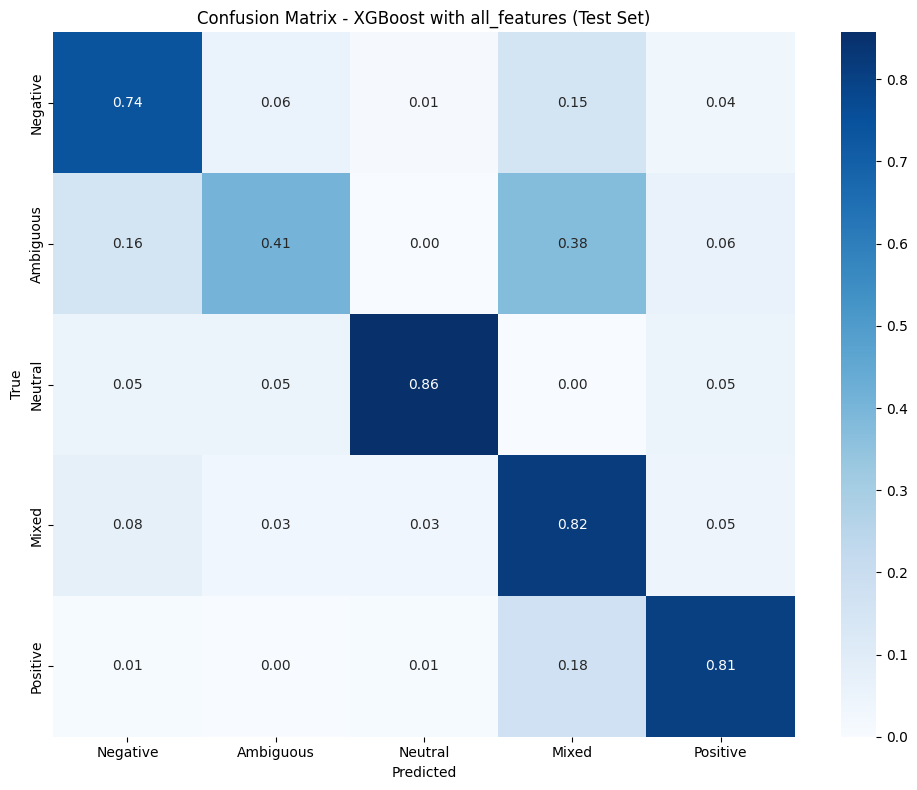

In [17]:
# Get the best model and evaluate on test set
best_model = best_model_row['Trained Model']
best_dataset = best_model_row['Dataset']

# Get test data
X_test = datasets[best_dataset]['test_X']
y_test = datasets[best_dataset]['test_y'].map(label_mapping).values if isinstance(datasets[best_dataset]['test_y'], pd.Series) else datasets[best_dataset]['test_y']

# Make predictions
y_pred = best_model.predict(X_test)

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
test_recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
test_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"\nTest Set Results for {best_model_row['Model']} with {best_dataset}:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1 Score: {test_f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_mapping.keys()))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=label_mapping.keys(), 
            yticklabels=label_mapping.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - {best_model_row["Model"]} with {best_dataset} (Test Set)')
plt.tight_layout()
plt.show()

---
## 5. Error Analysis

Total misclassified examples: 89 out of 375


,True Sentiment,Predicted Sentiment
21,Negative,Mixed
52,Ambiguous,Negative
53,Negative,Positive
41,Positive,Mixed
44,Positive,Mixed
17,Mixed,Positive
78,Ambiguous,Mixed
12,Positive,Mixed
19,Negative,Mixed
55,Ambiguous,Mixed



Most common misclassifications:


,True Sentiment,Predicted Sentiment,Count
14,Positive,Mixed,19
8,Negative,Mixed,13
0,Ambiguous,Mixed,12
4,Mixed,Negative,10
6,Mixed,Positive,6


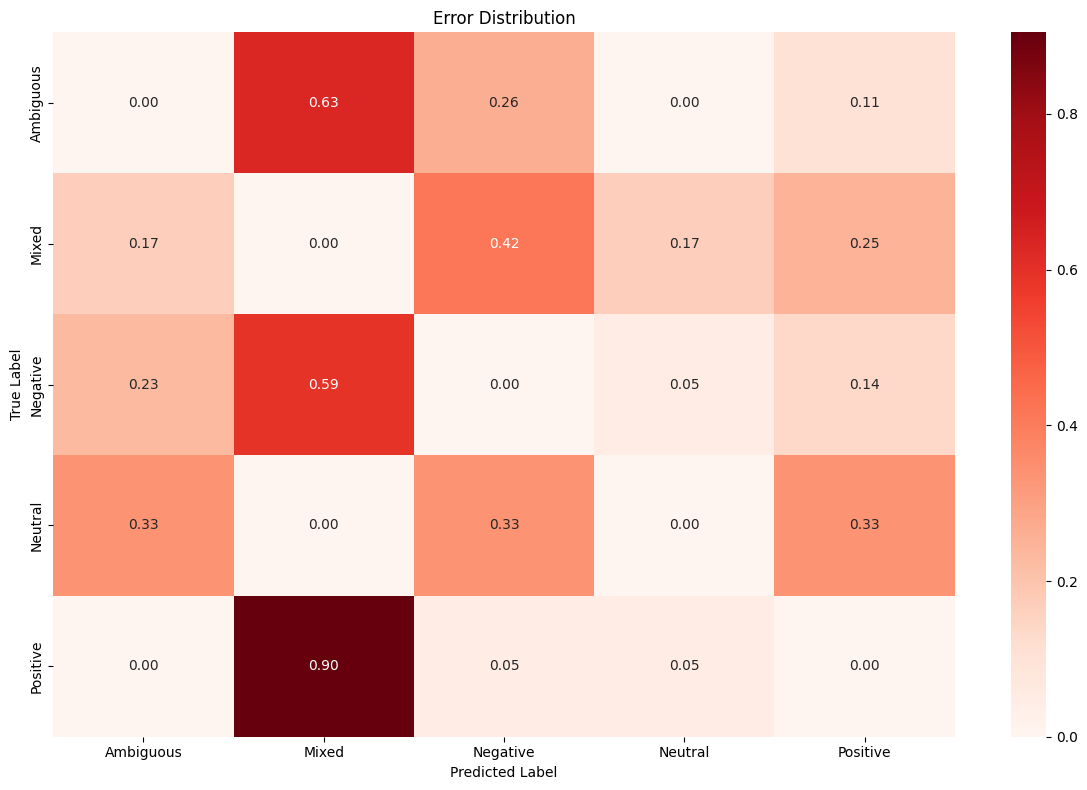

In [19]:
# Get misclassified examples from the test set
misclassified_indices = np.where(y_pred != y_test)[0]
misclassified_data = []

# Get text and metadata for misclassified examples
for idx in misclassified_indices:
    true_label = inv_label_mapping[y_test[idx]]
    pred_label = inv_label_mapping[y_pred[idx]]
    
    # We don't have access to the original text, so just skip that part
    misclassified_data.append({
        'True Sentiment': true_label,
        'Predicted Sentiment': pred_label
    })

misclassified_df = pd.DataFrame(misclassified_data)

# Display a sample of misclassified examples
print(f"Total misclassified examples: {len(misclassified_df)} out of {len(y_test)}")
display(misclassified_df.sample(min(10, len(misclassified_df))))

# Analyze error patterns
error_counts = misclassified_df.groupby(['True Sentiment', 'Predicted Sentiment']).size().reset_index()
error_counts.columns = ['True Sentiment', 'Predicted Sentiment', 'Count']
error_counts = error_counts.sort_values('Count', ascending=False)

print("\nMost common misclassifications:")
display(error_counts.head(5))

# Plot confusion specifically for errors
plt.figure(figsize=(12, 8))
error_matrix = pd.crosstab(
    misclassified_df['True Sentiment'], 
    misclassified_df['Predicted Sentiment'], 
    normalize='index'
)
sns.heatmap(error_matrix, annot=True, cmap='Reds', fmt='.2f')
plt.title('Error Distribution')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()